In [16]:
from dotenv import load_dotenv

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import dlib
from pathlib import Path


class Config:
    """환경 변수 및 모듈 간 규격 클래스"""
    """상황에 맞게 경로와 규격을 수정 후 사용할 것"""
    
    def __init__(self, default_size: int):
        """dotenv 위치 찾기 + 로드"""
        self.root_path = self._find_root()
        self.dotenv_path = self.root_path / ".env" # 또는 self.dotenv_path = self.root_path / ".env"
        load_dotenv(self.dotenv_path)

        """이미지와 모델 디렉토리 인식"""
        self._images_dir = self.root_path / "Computer_Vision/CV01/data/images"
        self._models_dir = self.root_path / "Computer_Vision/models"
        self.default_size = default_size

    def _find_root(self, marker: str=".env") -> Path:
        """프로젝트 최상단 경로를 찾는 함수"""
        """.env를 마커로 사용"""
        current_cwd = Path().cwd().resolve()
        for parent in current_cwd.parents:
            if (parent / marker).exists():
                return parent

    def get_image_path(self, image_name: str) -> Path:
        """이미지 주소 획득"""
        return self._images_dir / image_name
        
    def get_model_path(self, model_name: str) -> Path:
        """모델 주소 획득"""
        return self._models_dir / model_name


class ImageLoader:
    """이미지 로더: 경로 문제 생길 시 Config클래스 확인"""

    def __init__(self, image_path):
        self.img_bgr = cv2.imread(image_path, -1)
        self.img_bgr_copy = self.img_bgr.copy()
        self.img_rgb = cv2.cvtColor(self.img_bgr, cv2.COLOR_BGR2RGB)
        self.img_rgb_copy = self.img_rgb.copy()
    
    def show_image(self):
        plt.imshow(self.img_rgb)
        plt.show()
        print("원본 이미지 로드 완료")



In [ ]:
class FaceLoader(ImageLoader):
    def __init__(self, image_path):
        super().__init__()
        self.detector_hog = dlib.get_frontal_face_detector()

    def get_box(self):
        self.dlib_rects = self.detector_hog(self.img_rgb, 1)
        
        for self.dlib_rect in self.dlib_rects:
            self.l = self.dlib_rect.left()
            self.t = self.dlib_rect.top()
            self.r = self.dlib_rect.right()
            self.b = self.dlib_rect.bottom()

            cv2.regtangle(self.img_rgb, (self,l, ), ())

        


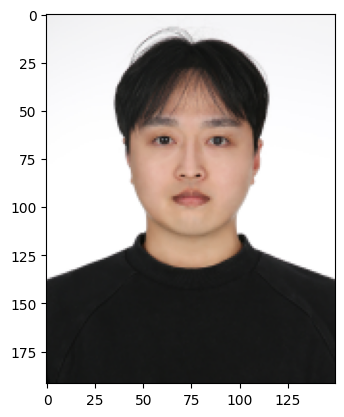

In [14]:
def run():
    cv01_config = Config(63)
    face_path = cv01_config.get_image_path("me.png")

    img_loader = ImageLoader(face_path)
    img_loader.show_image()

run()